# 🏌️ AI Golf Coach

Drop in a video of your golf swing and get detailed coaching feedback powered by **Google Gemini** (free).

### How it works:
1. Set your free Gemini API key
2. Point to your swing video
3. OpenCV extracts evenly-spaced frames
4. Gemini analyzes your form
5. Get a full coaching report

**Get a free API key at:** https://aistudio.google.com → Get API Key

In [1]:
# Cell 1 — Install dependencies (run once)
import subprocess
subprocess.run(['pip3', 'install', 'opencv-python', 'google-generativeai', 'matplotlib', 'Pillow'], check=True)
print('✅ All packages installed!')

Defaulting to user installation because normal site-packages is not writeable
✅ All packages installed!


You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9 -m pip install --upgrade pip' command.


In [ ]:
# Cell 2 — Set your API key
import google.generativeai as genai

GEMINI_API_KEY = "key"  # <-- paste your key here
# Get one free at: https://aistudio.google.com

genai.configure(api_key=GEMINI_API_KEY)
print('✅ API key set!')

/Users/ryaanmahmood/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.7). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/ryaanmahmood/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ryaanmahmood/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google wil

✅ API key set!


/var/folders/5z/p4jhx3kx48j7d9z08r1x13yh0000gn/T/ipykernel_41351/757008547.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
# Cell 3 — Import libraries
import cv2
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
from IPython.display import display, Markdown

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [4]:
# Cell 4 — Extract frames from your video

def extract_frames(video_path, output_dir, num_frames=5):
    """
    Extracts evenly-spaced frames from a video.
    Frames are sampled from 10%-90% of the video to capture the full swing.
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)

    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}\nMake sure your video is in the videos/ or test_video/ folder.")

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True)

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps

    print(f"📹 Video: {video_path.name}")
    print(f"   Duration: {duration:.1f}s | FPS: {fps:.0f} | Total frames: {total_frames}")

    # Sample from 10% to 90% to get the full swing arc
    start = int(total_frames * 0.10)
    end   = int(total_frames * 0.90)
    indices = [int(start + (end - start) * i / (num_frames - 1)) for i in range(num_frames)]

    saved = []
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            p = output_dir / f"frame_{i+1:03d}.jpg"
            cv2.imwrite(str(p), frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
            saved.append(p)
            print(f"   ✅ Frame {i+1}/{num_frames} saved")

    cap.release()
    print(f"\n🎞️  {len(saved)} frames extracted to '{output_dir}'")
    return saved


# =============================================
VIDEO_FILE = "IMG_2409.MOV"      # video is in the same folder as the notebook
NUM_FRAMES = 5
# =============================================

VIDEO_NAME = Path(VIDEO_FILE).stem
FRAMES_DIR = f"frames_{VIDEO_NAME}"   # saves frames right here too

frame_paths = extract_frames(VIDEO_FILE, FRAMES_DIR, num_frames=NUM_FRAMES)

📹 Video: IMG_2409.MOV
   Duration: 7.5s | FPS: 30 | Total frames: 224
   ✅ Frame 1/5 saved
   ✅ Frame 2/5 saved
   ✅ Frame 3/5 saved
   ✅ Frame 4/5 saved
   ✅ Frame 5/5 saved

🎞️  5 frames extracted to 'frames_IMG_2409'


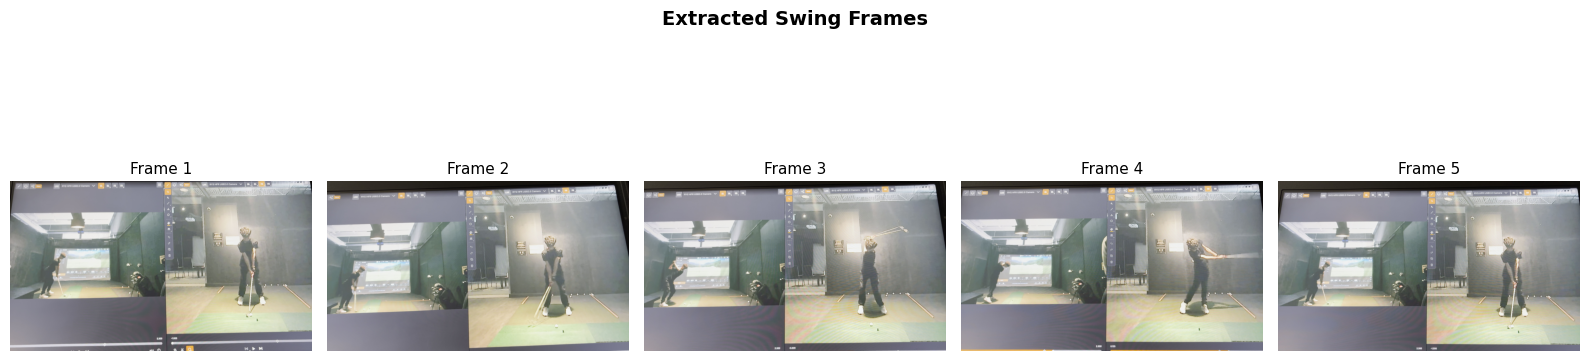

In [5]:
# Cell 5 — Preview the extracted frames

fig, axes = plt.subplots(1, len(frame_paths), figsize=(16, 5))
if len(frame_paths) == 1:
    axes = [axes]

for i, (ax, p) in enumerate(zip(axes, frame_paths)):
    ax.imshow(mpimg.imread(str(p)))
    ax.set_title(f"Frame {i+1}", fontsize=11)
    ax.axis('off')

plt.suptitle("Extracted Swing Frames", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Analyze your swing with Gemini

def analyze_swing(frame_paths, concerns=None):
    """
    Sends frames to Gemini 1.5 Flash and returns a detailed golf coaching report.
    """
    print(f"⏳ Sending {len(frame_paths)} frames to Gemini...")

    model = genai.GenerativeModel("gemini-2.0-flash")  # free tier

    # Load frames as PIL images
    images = [Image.open(str(p)) for p in frame_paths]

    concerns_text = f"\nThe golfer is specifically concerned about: {concerns}" if concerns else ""

    prompt = f"""You are an expert golf instructor with 20+ years of experience analyzing swings.

I've sent you {len(frame_paths)} sequential frames captured evenly across a golf swing video.
Analyze the complete swing sequence and give a detailed coaching report:

## 1. Setup & Address
- Stance width, ball position, grip, posture, spine angle, alignment

## 2. Takeaway & Backswing
- Club path on takeaway, shoulder turn, hip rotation, wrist hinge, weight shift, top-of-backswing position

## 3. Downswing & Impact
- Transition sequence, lag maintenance, weight transfer, hip clearance, club face at impact, shaft lean

## 4. Follow-Through & Finish
- Extension through the ball, body rotation, balance, finish position

## 5. Top 3 Problems to Fix
For each problem: what you see, why it hurts performance, and one specific drill to fix it.

## 6. Ratings (out of 10)
Setup / Backswing / Downswing / Impact / Finish
{concerns_text}

Be specific. Reference what you actually observe in the frames. Give actionable coaching advice."""

    response = model.generate_content([prompt] + images)
    return response.text


# =============================================
# OPTIONAL: add specific concerns
CONCERNS = ""  # e.g. "I tend to slice" or "my hips don't clear" or leave blank
# =============================================

analysis = analyze_swing(frame_paths, concerns=CONCERNS or None)
print("✅ Analysis complete!\n")

⏳ Sending 5 frames to Gemini...


ResourceExhausted: 429 Your prepayment credits are depleted. Please go to AI Studio at https://ai.studio/projects to manage your project and billing. Learn more at https://ai.google.dev/gemini-api/docs/billing#prepay. 

In [ ]:
# Cell 7 — Display your coaching report
display(Markdown(analysis))

In [ ]:
# Cell 8 — Save the report to a file
out = Path(f"../analysis_{VIDEO_NAME}.md")
out.write_text(f"# Golf Swing Analysis — {VIDEO_NAME}\n\n" + analysis)
print(f"✅ Report saved to: {out}")